# 04. Station Expansion Evaluation

This notebook answers the production question:

**Does adding more stations improve forecasting score and generalization, or does it just add noise?**

Primary mode for this notebook is now the **manual station CSV workflow**.

Recommended run order:
1. `01_Global_Forecast_Error_Reduction_Plan.ipynb` for the full action plan
2. `02_Phase1_Pipeline.ipynb` if you changed local processed inputs
3. Put manually downloaded station CSVs under `data/processed/observation_cache/`
4. Run this notebook to quality-gate and evaluate the broader station scope
5. `05_Forecasting.ipynb` for model-level retraining after the scope decision

Discovery and live API fetch are still available as fallback options, but they are no longer the default path.


In [18]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from airpulse.station_expansion import (
    StationDiscoveryConfig,
    StationHistoryFetchConfig,
    discover_candidate_stations,
    fetch_station_histories_from_api,
    load_candidate_station_catalog,
    merge_station_histories,
)
from airpulse.station_selection import (
    StationEligibilityRules,
    build_station_quality_profiles,
    select_eligible_stations,
)
from airpulse.dataset_builder import build_training_universes
from airpulse.forecast_evaluation import (
    RollingEvaluationConfig,
    evaluate_leave_station_out,
    evaluate_station_universes,
    save_evaluation_report,
)
from airpulse.station_experiment import infer_baseline_station_keys, recommend_production_universe
from airpulse.storage import load_all_raw_station_histories, load_observation_cache_histories

print('Project root:', PROJECT_ROOT)


Project root: C:\Users\rbeyz\Desktop\AirPulse_Global


## Configuration

- Put the manually downloaded station CSVs in `data/processed/observation_cache/`.
- Keep `USE_MANUAL_OBSERVATION_CACHE = True` to use those 50 CSV files as the primary expansion source.
- Turn on `RUN_STATION_DISCOVERY = True` only if you explicitly want to rebuild the WAQI candidate catalog.
- Turn on `RUN_API_FETCH = True` only if you explicitly want to fetch more history from APIs.
- Use `FAST_MODE = True` for the first decision pass. This disables Prophet, reduces horizons, and cuts rolling splits so the notebook finishes much faster.
- Target for this phase: confirm that the manual station universe is clean enough for retraining.


In [19]:
USE_MANUAL_OBSERVATION_CACHE = True
RUN_STATION_DISCOVERY = False
RUN_API_FETCH = False
FAST_MODE = True
TARGET_POLLUTANT = 'pm25'
BASELINE_STATION_KEYS = None
HELDOUT_STATION_COUNT = 2
MIN_TARGET_ACCEPTED_STATIONS = 50
MANUAL_CACHE_DIR = PROJECT_ROOT / 'data' / 'processed' / 'observation_cache'
EXPANDED_HISTORY_CACHE_PATH = PROJECT_ROOT / 'data' / 'processed' / 'station_expansion' / 'fetched_station_histories.parquet'
FETCH_LOG_CACHE_PATH = PROJECT_ROOT / 'data' / 'processed' / 'station_expansion' / 'fetched_station_history_log.csv'

COUNTRY_CITY_SEEDS = {
    'TR': ['Istanbul', 'Ankara', 'Izmir', 'Bursa', 'Antalya'],
    'DE': ['Berlin', 'Munich', 'Hamburg', 'Cologne', 'Frankfurt'],
    'FR': ['Paris', 'Lyon', 'Marseille'],
    'GB': ['London', 'Manchester', 'Birmingham'],
    'ES': ['Madrid', 'Barcelona', 'Valencia'],
}
seed_rows = [
    {'city': city, 'country': country}
    for country, cities in COUNTRY_CITY_SEEDS.items()
    for city in cities
]
seed_df = pd.DataFrame(seed_rows)

discovery_config = StationDiscoveryConfig(
    max_search_results_per_seed=12,
    max_stations_per_seed=8,
    request_pause_seconds=1.0,
)

selection_rules = StationEligibilityRules(
    target_pollutant=TARGET_POLLUTANT,
    minimum_history_days=180,
    maximum_missing_ratio=0.35,
    minimum_recent_availability=0.60,
    minimum_target_coverage=0.70,
    maximum_gap_ratio=0.25,
    minimum_observations=120,
)

fetch_config = StationHistoryFetchConfig(
    history_days=365 * 3,
    minimum_real_history_days=90,
    write_raw_csv=False,
    request_pause_seconds=1.0,
    fetch_max_retries=3,
    fetch_retry_pause_seconds=3.0,
)

if FAST_MODE:
    evaluation_config = RollingEvaluationConfig(
        horizons=(1,),
        rolling_train_min_days=365,
        rolling_test_window_days=14,
        rolling_step_days=120,
        high_pollution_threshold=55.0,
        target_pollutant=TARGET_POLLUTANT,
    )
    ROLLING_MODELS = ('naive_persistence', 'seasonal_naive', 'ridge', 'gradient_boosting')
    LSO_MODELS = ('naive_persistence', 'seasonal_naive', 'ridge', 'gradient_boosting')
    ACTIVE_SCOPE_NAMES = ['baseline_8_station', 'expanded_curated']
else:
    evaluation_config = RollingEvaluationConfig(
        horizons=(1, 3, 7),
        rolling_train_min_days=365,
        rolling_test_window_days=30,
        rolling_step_days=30,
        high_pollution_threshold=55.0,
        target_pollutant=TARGET_POLLUTANT,
    )
    ROLLING_MODELS = ('naive_persistence', 'seasonal_naive', 'ridge', 'random_forest', 'hist_gradient_boosting', 'prophet_stationwise')
    LSO_MODELS = ('naive_persistence', 'seasonal_naive', 'ridge', 'random_forest', 'hist_gradient_boosting')
    ACTIVE_SCOPE_NAMES = ['baseline_8_station', 'expanded_curated', 'expanded_exploratory']

ARTIFACT_DIR = PROJECT_ROOT / 'data' / 'processed' / 'station_expansion'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('USE_MANUAL_OBSERVATION_CACHE:', USE_MANUAL_OBSERVATION_CACHE)
print('RUN_STATION_DISCOVERY:', RUN_STATION_DISCOVERY)
print('RUN_API_FETCH:', RUN_API_FETCH)
print('FAST_MODE:', FAST_MODE)
print('Manual cache dir:', MANUAL_CACHE_DIR)
print('Minimum accepted station target:', MIN_TARGET_ACCEPTED_STATIONS)
print('Rolling models:', ROLLING_MODELS)
print('Active scopes:', ACTIVE_SCOPE_NAMES)
print('Artifact dir:', ARTIFACT_DIR)


USE_MANUAL_OBSERVATION_CACHE: True
RUN_STATION_DISCOVERY: False
RUN_API_FETCH: False
FAST_MODE: True
Manual cache dir: C:\Users\rbeyz\Desktop\AirPulse_Global\data\processed\observation_cache
Minimum accepted station target: 50
Rolling models: ('naive_persistence', 'seasonal_naive', 'ridge', 'gradient_boosting')
Active scopes: ['baseline_8_station', 'expanded_curated']
Artifact dir: C:\Users\rbeyz\Desktop\AirPulse_Global\data\processed\station_expansion


In [20]:
baseline_history_df = load_all_raw_station_histories()
manual_history_df = load_observation_cache_histories() if USE_MANUAL_OBSERVATION_CACHE else pd.DataFrame(columns=['station_key', 'date'])
existing_catalog_df = load_candidate_station_catalog()

if RUN_STATION_DISCOVERY:
    discovered_catalog_df = discover_candidate_stations(seed_df, config=discovery_config)
    candidate_catalog_df = pd.concat([existing_catalog_df, discovered_catalog_df], ignore_index=True).drop_duplicates(subset=['station_key'], keep='last')
else:
    discovered_catalog_df = pd.DataFrame(columns=existing_catalog_df.columns)
    candidate_catalog_df = existing_catalog_df.copy()

baseline_station_keys = list(BASELINE_STATION_KEYS or infer_baseline_station_keys(baseline_history_df))

print('Baseline rows:', len(baseline_history_df))
print('Baseline stations:', baseline_history_df['station_key'].nunique() if not baseline_history_df.empty else 0)
print('Manual history rows:', len(manual_history_df))
print('Manual stations:', manual_history_df['station_key'].nunique() if not manual_history_df.empty else 0)
print('Existing catalog rows:', len(existing_catalog_df))
print('Discovered catalog rows:', len(discovered_catalog_df))
print('Merged candidate catalog rows:', len(candidate_catalog_df))
print('Baseline station keys:', baseline_station_keys)

display(candidate_catalog_df.head(10))


Baseline rows: 146288
Baseline stations: 48
Manual history rows: 146288
Manual stations: 48
Existing catalog rows: 325
Discovered catalog rows: 0
Merged candidate catalog rows: 325
Baseline station keys: ['catladikapi', 'istanbulaksaray', 'istanbulalibeykoy', 'istanbulbesiktas', 'istanbulesenyurt', 'istanbulkagithane', 'istanbulmecidiyekoy', 'istanbultr']


,station_key,station_name,waqi_uid,latitude,longitude,seed_city,seed_country,source,last_updated
0,a10westamsterdam,"A10-west, Amsterdam",3716,52.339498,4.841021,Amsterdam,NL,waqi_search,2026-03-25T18:33:13.905205
1,a7sudlyonnaisfrance,"A7 Sud Lyonnais, France",3023,45.720082,4.818159,Lyon,FR,waqi_search,2026-03-25T18:32:25.327764
2,agiasofiagreece,"Agia Sofia, Greece",12413,40.633774,22.945288,Thessaloniki,GR,waqi_search,2026-03-25T18:33:27.110440
3,alejakrasiskiegokrakwmaopolskapoland,"Aleja KrasiÅ„skiego, KrakÃ³w, MaÅ‚opolska, Poland",3402,50.057678,19.926189,Krakow,PL,waqi_search,2026-03-25T18:33:09.482839
4,alphonsarienstraatschiedam,"Alphons Arienstraat, Schiedam",5285,51.921390,4.401390,Rotterdam,NL,waqi_search,2026-03-25T18:33:16.084971
5,altonaelbhanghamburggermany,"Altona-Elbhang, Hamburg, Germany",6126,53.545245,9.944890,Hamburg,DE,waqi_search,2026-03-25T18:32:16.664799
6,amsterdam,Amsterdam,5771,52.370216,4.895168,Amsterdam,NL,waqi_search,2026-03-25T18:33:13.905205
7,anandvihardelhidelhiindia,"Anand Vihar, Delhi, Delhi, India",2553,28.650800,77.315200,Delhi,IN,waqi_search,2026-03-25T18:33:38.155216
8,ankarabahcelievlerturkey,"Ankara (Bahcelievler), Turkey",4094,39.918323,32.822905,Ankara,TR,waqi_search,2026-03-25T18:32:03.389275
9,ankarademetevlerturkey,"Ankara (Demetevler), Turkey",4096,39.967739,32.795670,Ankara,TR,waqi_search,2026-03-25T18:32:03.389275


In [21]:
if USE_MANUAL_OBSERVATION_CACHE and not manual_history_df.empty:
    expanded_history_df = manual_history_df.copy()
    fetch_log_df = pd.DataFrame({
        'station_key': sorted(expanded_history_df['station_key'].dropna().astype(str).unique()),
        'status': 'manual_cache',
        'reason': '',
        'row_count': [int((expanded_history_df['station_key'] == station_key).sum()) for station_key in sorted(expanded_history_df['station_key'].dropna().astype(str).unique())],
    })
elif RUN_API_FETCH:
    expanded_history_df, fetch_log_df = fetch_station_histories_from_api(candidate_catalog_df, config=fetch_config)
elif EXPANDED_HISTORY_CACHE_PATH.exists():
    expanded_history_df = pd.read_parquet(EXPANDED_HISTORY_CACHE_PATH)
    fetch_log_df = pd.read_csv(FETCH_LOG_CACHE_PATH) if FETCH_LOG_CACHE_PATH.exists() else pd.DataFrame(columns=['station_key', 'waqi_uid', 'status', 'reason', 'row_count'])
else:
    expanded_history_df = pd.DataFrame(columns=['station_key', 'date'])
    fetch_log_df = pd.DataFrame(columns=['station_key', 'waqi_uid', 'status', 'reason', 'row_count'])

print('Expanded history rows from manual/API/cache:', len(expanded_history_df))
display(fetch_log_df.head(10))


Expanded history rows from manual/API/cache: 146288


,station_key,status,reason,row_count
0,alejakrasiskiegokrakwmaopolska,manual_cache,,4312
1,alexandranaqicityofjohannesburg,manual_cache,,1502
2,amsterdam,manual_cache,,4253
3,ankara,manual_cache,,1
4,antalya,manual_cache,,4262
5,aristotelous,manual_cache,,2307
6,avdfranciavalnciavalencia,manual_cache,,4014
7,barcelonapalaureialcatalunya,manual_cache,,4143
8,beijing,manual_cache,,10
9,beograddragiamiovi,manual_cache,,1132


## Station Quality Gating

This section builds candidate, accepted, and rejected station tables with explicit rejection reasons.


In [22]:
merged_history_df = merge_station_histories(baseline_history_df, expanded_history_df)
quality_df = build_station_quality_profiles(merged_history_df, rules=selection_rules)

if not candidate_catalog_df.empty:
    candidate_table_df = candidate_catalog_df.merge(quality_df, on='station_key', how='left', suffixes=('', '_quality'))
    if 'station_name_quality' in candidate_table_df.columns:
        candidate_table_df['station_name'] = candidate_table_df['station_name'].fillna(candidate_table_df['station_name_quality'])
        candidate_table_df = candidate_table_df.drop(columns=['station_name_quality'])
else:
    candidate_table_df = quality_df.copy()

if not fetch_log_df.empty:
    candidate_table_df = candidate_table_df.merge(
        fetch_log_df[['station_key', 'status', 'reason']].rename(columns={'status': 'fetch_status', 'reason': 'fetch_reason'}),
        on='station_key',
        how='left',
    )

candidate_table_df, accepted_df, rejected_df = select_eligible_stations(candidate_table_df, rules=selection_rules)

print('Candidate stations:', len(candidate_table_df))
print('Accepted stations:', len(accepted_df))
print('Rejected stations:', len(rejected_df))

display(candidate_table_df.head(20))


Candidate stations: 325
Accepted stations: 5
Rejected stations: 320


,station_key,station_name,waqi_uid,latitude,longitude,seed_city,seed_country,source,last_updated,num_observations,...,outlier_ratio,recent_availability,volatility_std,volatility_iqr,weather_coverage_alignment,quality_score,fetch_status,fetch_reason,rejection_reasons,selection_status
0,a10westamsterdam,"A10-west, Amsterdam",3716,52.339498,4.841021,Amsterdam,NL,waqi_search,2026-03-25T18:33:13.905205,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"history_days<180, num_observations<120, missin...",rejected
1,a7sudlyonnaisfrance,"A7 Sud Lyonnais, France",3023,45.720082,4.818159,Lyon,FR,waqi_search,2026-03-25T18:32:25.327764,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"history_days<180, num_observations<120, missin...",rejected
2,agiasofiagreece,"Agia Sofia, Greece",12413,40.633774,22.945288,Thessaloniki,GR,waqi_search,2026-03-25T18:33:27.110440,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"history_days<180, num_observations<120, missin...",rejected
3,alejakrasiskiegokrakwmaopolskapoland,"Aleja KrasiÅ„skiego, KrakÃ³w, MaÅ‚opolska, Poland",3402,50.057678,19.926189,Krakow,PL,waqi_search,2026-03-25T18:33:09.482839,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"history_days<180, num_observations<120, missin...",rejected
4,alphonsarienstraatschiedam,"Alphons Arienstraat, Schiedam",5285,51.921390,4.401390,Rotterdam,NL,waqi_search,2026-03-25T18:33:16.084971,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"history_days<180, num_observations<120, missin...",rejected
5,altonaelbhanghamburggermany,"Altona-Elbhang, Hamburg, Germany",6126,53.545245,9.944890,Hamburg,DE,waqi_search,2026-03-25T18:32:16.664799,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"history_days<180, num_observations<120, missin...",rejected
6,amsterdam,Amsterdam,5771,52.370216,4.895168,Amsterdam,NL,waqi_search,2026-03-25T18:33:13.905205,4253.0,...,0.024122,1.0,22.062654,25.0,1.0,0.933185,manual_cache,,,accepted
7,anandvihardelhidelhiindia,"Anand Vihar, Delhi, Delhi, India",2553,28.650800,77.315200,Delhi,IN,waqi_search,2026-03-25T18:33:38.155216,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"history_days<180, num_observations<120, missin...",rejected
8,ankarabahcelievlerturkey,"Ankara (Bahcelievler), Turkey",4094,39.918323,32.822905,Ankara,TR,waqi_search,2026-03-25T18:32:03.389275,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"history_days<180, num_observations<120, missin...",rejected
9,ankarademetevlerturkey,"Ankara (Demetevler), Turkey",4096,39.967739,32.795670,Ankara,TR,waqi_search,2026-03-25T18:32:03.389275,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"history_days<180, num_observations<120, missin...",rejected


In [23]:
print('Accepted stations preview')
display(accepted_df.head(20))

print('Rejected stations preview')
display(rejected_df[['station_key', 'station_name', 'selection_status', 'rejection_reasons']].head(20))


Accepted stations preview


,station_key,station_name,waqi_uid,latitude,longitude,seed_city,seed_country,source,last_updated,num_observations,...,outlier_ratio,recent_availability,volatility_std,volatility_iqr,weather_coverage_alignment,quality_score,fetch_status,fetch_reason,rejection_reasons,selection_status
0,amsterdam,Amsterdam,5771,52.370216,4.895168,Amsterdam,NL,waqi_search,2026-03-25T18:33:13.905205,4253.0,...,0.024122,1.0,22.062654,25.0,1.0,0.933185,manual_cache,,,accepted
1,london,London,5724,51.507351,-0.127758,London,GB,waqi_search,2026-03-25T18:32:56.440719,4460.0,...,0.023381,1.0,22.474248,24.0,1.0,0.985942,manual_cache,,,accepted
2,madrid,Madrid,5725,40.416775,-3.703790,Madrid,ES,waqi_search,2026-03-25T18:32:45.435092,4296.0,...,0.011475,1.0,21.409453,26.0,1.0,0.952128,manual_cache,,,accepted
3,paris,Paris,5722,48.856614,2.352222,Paris,FR,waqi_search,2026-03-25T18:32:23.151014,4333.0,...,0.019907,1.0,21.799705,25.0,1.0,0.941153,manual_cache,,,accepted
4,rotterdam,Rotterdam,5772,51.930833,4.479167,Rotterdam,NL,waqi_search,2026-03-25T18:33:16.084971,4228.0,...,0.019663,1.0,23.066446,26.0,1.0,0.906316,manual_cache,,,accepted


Rejected stations preview


,station_key,station_name,selection_status,rejection_reasons
0,a10westamsterdam,"A10-west, Amsterdam",rejected,"history_days<180, num_observations<120, missin..."
1,a7sudlyonnaisfrance,"A7 Sud Lyonnais, France",rejected,"history_days<180, num_observations<120, missin..."
2,agiasofiagreece,"Agia Sofia, Greece",rejected,"history_days<180, num_observations<120, missin..."
3,alejakrasiskiegokrakwmaopolskapoland,"Aleja KrasiÅ„skiego, KrakÃ³w, MaÅ‚opolska, Poland",rejected,"history_days<180, num_observations<120, missin..."
4,alphonsarienstraatschiedam,"Alphons Arienstraat, Schiedam",rejected,"history_days<180, num_observations<120, missin..."
5,altonaelbhanghamburggermany,"Altona-Elbhang, Hamburg, Germany",rejected,"history_days<180, num_observations<120, missin..."
6,anandvihardelhidelhiindia,"Anand Vihar, Delhi, Delhi, India",rejected,"history_days<180, num_observations<120, missin..."
7,ankarabahcelievlerturkey,"Ankara (Bahcelievler), Turkey",rejected,"history_days<180, num_observations<120, missin..."
8,ankarademetevlerturkey,"Ankara (Demetevler), Turkey",rejected,"history_days<180, num_observations<120, missin..."
9,ankarakayasturkey,"Ankara (Kayas), Turkey",rejected,"history_days<180, num_observations<120, missin..."


## Dataset Universes

We construct three comparable scopes:
- `baseline_8_station`
- `expanded_curated`
- `expanded_exploratory`


In [24]:
curated_station_keys = accepted_df['station_key'].dropna().astype(str).tolist()
exploratory_station_keys = candidate_table_df['station_key'].dropna().astype(str).tolist() if not candidate_table_df.empty else curated_station_keys

dataset_scopes, dataset_scope_summary_df = build_training_universes(
    merged_history_df,
    baseline_station_keys=baseline_station_keys,
    curated_station_keys=curated_station_keys or baseline_station_keys,
    exploratory_station_keys=exploratory_station_keys or curated_station_keys or baseline_station_keys,
)
dataset_scopes = {name: df for name, df in dataset_scopes.items() if name in ACTIVE_SCOPE_NAMES}
dataset_scope_summary_df = dataset_scope_summary_df[dataset_scope_summary_df['dataset_scope'].isin(ACTIVE_SCOPE_NAMES)].reset_index(drop=True)

display(dataset_scope_summary_df)


,dataset_scope,stations,rows,date_min,date_max
0,baseline_8_station,2,2,2026-03-18,2026-03-18
1,expanded_curated,5,21570,2013-12-31,2026-03-25


## Rolling Time-Series Evaluation

This is the main production-style comparison: same models, same horizons, different station universes.

When `FAST_MODE = True`, the notebook runs a lightweight decision pass first:
- horizon `t+1` only
- wider rolling step
- no Prophet
- only baseline vs expanded curated scopes


In [25]:
rolling_report = evaluate_station_universes(dataset_scopes, config=evaluation_config, models=ROLLING_MODELS)
rolling_overall_df = rolling_report['overall_leaderboard']
rolling_station_df = rolling_report['per_station_leaderboard']
rolling_horizon_df = rolling_report['per_horizon_leaderboard']
rolling_scope_summary_df = rolling_report['dataset_scope_summary']
rolling_scope_comparison_df = rolling_report['scope_comparison']

print('Rolling overall leaderboard')
display(rolling_overall_df.head(30))

print('Rolling scope comparison')
display(rolling_scope_comparison_df)


[eval] starting rolling evaluation for 2 scope(s), 4 model(s), horizons=(1,)
[eval] scope 'baseline_8_station': 2 rows, 2 station(s), 0 rolling split(s)
[eval] scope 'expanded_curated': 21,570 rows, 5 station(s), 35 rolling split(s)
[eval] scope 'expanded_curated' split 1/35: train<= 2015-01-01 test 2015-01-02..2015-01-15
[eval] scope 'expanded_curated' split 1/35 horizon t+1: fitting naive_persistence
[eval] scope 'expanded_curated' split 1/35 horizon t+1: fitting seasonal_naive
[eval] scope 'expanded_curated' split 1/35 horizon t+1: fitting ridge
[eval] scope 'expanded_curated' split 1/35 horizon t+1: fitting gradient_boosting
[eval] scope 'expanded_curated' split 2/35: train<= 2015-05-01 test 2015-05-02..2015-05-15
[eval] scope 'expanded_curated' split 2/35 horizon t+1: fitting naive_persistence
[eval] scope 'expanded_curated' split 2/35 horizon t+1: fitting seasonal_naive
[eval] scope 'expanded_curated' split 2/35 horizon t+1: fitting ridge
[eval] scope 'expanded_curated' split 2/3

,evaluation_mode,dataset_scope,model_name,horizon,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,rolling,expanded_curated,gradient_boosting,1,2308,10.842345,6.933094,14.023804,11.910348,0.848993,0.832237,0.840532
1,rolling,expanded_curated,ridge,1,2308,12.280153,8.038034,16.334570,13.259574,0.848521,0.786184,0.816164
2,rolling,expanded_curated,naive_persistence,1,2295,22.518905,15.363399,28.990136,23.580507,0.641758,0.643881,0.642818
3,rolling,expanded_curated,seasonal_naive,1,2302,27.731805,20.328410,36.895727,28.387182,0.485572,0.537445,0.510193


Rolling scope comparison


,evaluation_mode,dataset_scope,model_name,rmse,mae,smape,delta_vs_baseline_rmse,verdict


## Leave-Station-Out Evaluation

This tests whether a broader training universe generalizes better to unseen or less-represented stations.


In [26]:
heldout_station_keys = (curated_station_keys or baseline_station_keys)[-HELDOUT_STATION_COUNT:]
print('Held-out stations:', heldout_station_keys)


Held-out stations: ['paris', 'rotterdam']


In [27]:
leave_station_out_report = evaluate_leave_station_out(
    dataset_scopes,
    heldout_station_keys=heldout_station_keys,
    config=evaluation_config,
    models=LSO_MODELS,
)

lso_overall_df = leave_station_out_report['overall_leaderboard']
lso_station_df = leave_station_out_report['per_station_leaderboard']
lso_scope_summary_df = leave_station_out_report['dataset_scope_summary']
lso_scope_comparison_df = leave_station_out_report['scope_comparison']

print('Leave-station-out overall leaderboard')
display(lso_overall_df.head(30))

print('Leave-station-out scope comparison')
display(lso_scope_comparison_df)


Leave-station-out overall leaderboard


,evaluation_mode,dataset_scope,model_name,horizon,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,leave_station_out,expanded_curated,gradient_boosting,1,8236,13.981261,10.206250,18.939515,14.766737,0.767419,0.905617,0.830810
1,leave_station_out,expanded_curated,ridge,1,8236,16.427795,10.541747,19.208634,17.758542,0.764425,0.882166,0.819086
2,leave_station_out,expanded_curated,naive_persistence,1,8203,21.857860,16.204437,30.591351,22.909441,0.652212,0.651264,0.651738
3,leave_station_out,expanded_curated,seasonal_naive,1,8228,27.875420,20.609018,37.683159,29.250965,0.543743,0.543900,0.543822


Leave-station-out scope comparison


,evaluation_mode,dataset_scope,model_name,rmse,mae,smape,delta_vs_baseline_rmse,verdict


## Production Recommendation

A station universe should be promoted only if it helps the rolling forecast score and does not hurt held-out-station generalization.


In [28]:
recommendation_df = pd.concat([
    recommend_production_universe(rolling_scope_comparison_df),
    recommend_production_universe(lso_scope_comparison_df),
], ignore_index=True)

display(recommendation_df)


,evaluation_mode,recommended_scope,recommended_model,reason


## Single Model Runs

This section runs each model one by one so the outputs stay easier to read.
At the end, we combine the results into one comparison table.

In [29]:
from airpulse.forecast_evaluation import PROPHET_AVAILABLE

single_model_reports = {}
single_model_order = [
    'naive_persistence',
    'seasonal_naive',
    'ridge',
    'gradient_boosting',
    'prophet_stationwise',
]

single_model_labels = {
    'naive_persistence': 'Naive Persistence',
    'seasonal_naive': 'Seasonal Naive',
    'ridge': 'Ridge Regression',
    'gradient_boosting': 'Gradient Boosting',
    'prophet_stationwise': 'Prophet (Stationwise)',
}

def run_single_model_eval(model_name: str):
    label = single_model_labels.get(model_name, model_name)
    print(f'=== {label} ===')
    if model_name == 'prophet_stationwise' and not PROPHET_AVAILABLE:
        print('Prophet is not installed in this environment, so this run is skipped.')
        return None
    report = evaluate_station_universes(
        dataset_scopes,
        config=evaluation_config,
        models=(model_name,),
    )
    single_model_reports[model_name] = report
    overall_df = report['overall_leaderboard'].copy()
    station_df = report['per_station_leaderboard'].copy()
    scope_df = report['scope_comparison'].copy()
    if overall_df.empty:
        print('No evaluation rows were produced for this model.')
        return report
    display(overall_df)
    print('Per-station snapshot')
    display(station_df.head(10))
    if not scope_df.empty:
        print('Scope comparison')
        display(scope_df)
    return report

print('Single-model evaluation order:', single_model_order)
print('Active scopes:', list(dataset_scopes.keys()))
print('Evaluation config:', evaluation_config)

Single-model evaluation order: ['naive_persistence', 'seasonal_naive', 'ridge', 'gradient_boosting', 'prophet_stationwise']
Active scopes: ['baseline_8_station', 'expanded_curated']
Evaluation config: RollingEvaluationConfig(horizons=(1,), rolling_train_min_days=365, rolling_test_window_days=14, rolling_step_days=120, high_pollution_threshold=55.0, leaderboard_sort_metric='rmse', target_pollutant='pm25')


### 1. Naive Persistence

In [30]:
naive_report = run_single_model_eval('naive_persistence')

=== Naive Persistence ===
[eval] starting rolling evaluation for 2 scope(s), 1 model(s), horizons=(1,)
[eval] scope 'baseline_8_station': 2 rows, 2 station(s), 0 rolling split(s)
[eval] scope 'expanded_curated': 21,570 rows, 5 station(s), 35 rolling split(s)
[eval] scope 'expanded_curated' split 1/35: train<= 2015-01-01 test 2015-01-02..2015-01-15
[eval] scope 'expanded_curated' split 1/35 horizon t+1: fitting naive_persistence
[eval] scope 'expanded_curated' split 2/35: train<= 2015-05-01 test 2015-05-02..2015-05-15
[eval] scope 'expanded_curated' split 2/35 horizon t+1: fitting naive_persistence
[eval] scope 'expanded_curated' split 3/35: train<= 2015-08-29 test 2015-08-30..2015-09-12
[eval] scope 'expanded_curated' split 3/35 horizon t+1: fitting naive_persistence
[eval] scope 'expanded_curated' split 4/35: train<= 2015-12-27 test 2015-12-28..2016-01-10
[eval] scope 'expanded_curated' split 4/35 horizon t+1: fitting naive_persistence
[eval] scope 'expanded_curated' split 5/35: train

,evaluation_mode,dataset_scope,model_name,horizon,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,rolling,expanded_curated,naive_persistence,1,2295,22.518905,15.363399,28.990136,23.580507,0.641758,0.643881,0.642818


Per-station snapshot


,evaluation_mode,dataset_scope,model_name,horizon,station_key,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,rolling,expanded_curated,naive_persistence,1,paris,473,17.932278,13.638478,24.702051,18.812967,0.686916,0.671233,0.678984
1,rolling,expanded_curated,naive_persistence,1,madrid,448,21.037806,15.089286,27.558360,22.146738,0.686636,0.706161,0.696262
2,rolling,expanded_curated,naive_persistence,1,amsterdam,436,21.858490,15.422018,27.776314,23.233582,0.606452,0.598726,0.602564
3,rolling,expanded_curated,naive_persistence,1,rotterdam,450,22.144024,16.553333,38.049718,23.582801,0.455357,0.467890,0.461538
4,rolling,expanded_curated,naive_persistence,1,london,488,28.067432,16.137295,27.191188,28.838011,0.674528,0.677725,0.676123


### 2. Seasonal Naive

In [31]:
seasonal_naive_report = run_single_model_eval('seasonal_naive')

=== Seasonal Naive ===
[eval] starting rolling evaluation for 2 scope(s), 1 model(s), horizons=(1,)
[eval] scope 'baseline_8_station': 2 rows, 2 station(s), 0 rolling split(s)
[eval] scope 'expanded_curated': 21,570 rows, 5 station(s), 35 rolling split(s)
[eval] scope 'expanded_curated' split 1/35: train<= 2015-01-01 test 2015-01-02..2015-01-15
[eval] scope 'expanded_curated' split 1/35 horizon t+1: fitting seasonal_naive
[eval] scope 'expanded_curated' split 2/35: train<= 2015-05-01 test 2015-05-02..2015-05-15
[eval] scope 'expanded_curated' split 2/35 horizon t+1: fitting seasonal_naive
[eval] scope 'expanded_curated' split 3/35: train<= 2015-08-29 test 2015-08-30..2015-09-12
[eval] scope 'expanded_curated' split 3/35 horizon t+1: fitting seasonal_naive
[eval] scope 'expanded_curated' split 4/35: train<= 2015-12-27 test 2015-12-28..2016-01-10
[eval] scope 'expanded_curated' split 4/35 horizon t+1: fitting seasonal_naive
[eval] scope 'expanded_curated' split 5/35: train<= 2016-04-25 t

,evaluation_mode,dataset_scope,model_name,horizon,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,rolling,expanded_curated,seasonal_naive,1,2302,27.731805,20.32841,36.895727,28.387182,0.485572,0.537445,0.510193


Per-station snapshot


,evaluation_mode,dataset_scope,model_name,horizon,station_key,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,rolling,expanded_curated,seasonal_naive,1,paris,474,25.110221,19.371308,32.827122,25.080189,0.472803,0.515982,0.493450
1,rolling,expanded_curated,seasonal_naive,1,madrid,451,26.702226,19.651885,35.075972,27.591231,0.600917,0.617925,0.609302
2,rolling,expanded_curated,seasonal_naive,1,amsterdam,437,27.691542,20.574371,35.909851,28.362463,0.430233,0.471338,0.449848
3,rolling,expanded_curated,seasonal_naive,1,rotterdam,451,28.659481,21.796009,47.017680,29.506022,0.288732,0.376147,0.326693
4,rolling,expanded_curated,seasonal_naive,1,london,489,30.145794,20.306748,34.063530,31.184176,0.551282,0.611374,0.579775


### 3. Ridge Regression

In [32]:
ridge_report = run_single_model_eval('ridge')

=== Ridge Regression ===
[eval] starting rolling evaluation for 2 scope(s), 1 model(s), horizons=(1,)
[eval] scope 'baseline_8_station': 2 rows, 2 station(s), 0 rolling split(s)
[eval] scope 'expanded_curated': 21,570 rows, 5 station(s), 35 rolling split(s)
[eval] scope 'expanded_curated' split 1/35: train<= 2015-01-01 test 2015-01-02..2015-01-15
[eval] scope 'expanded_curated' split 1/35 horizon t+1: fitting ridge
[eval] scope 'expanded_curated' split 2/35: train<= 2015-05-01 test 2015-05-02..2015-05-15
[eval] scope 'expanded_curated' split 2/35 horizon t+1: fitting ridge
[eval] scope 'expanded_curated' split 3/35: train<= 2015-08-29 test 2015-08-30..2015-09-12
[eval] scope 'expanded_curated' split 3/35 horizon t+1: fitting ridge
[eval] scope 'expanded_curated' split 4/35: train<= 2015-12-27 test 2015-12-28..2016-01-10
[eval] scope 'expanded_curated' split 4/35 horizon t+1: fitting ridge
[eval] scope 'expanded_curated' split 5/35: train<= 2016-04-25 test 2016-04-26..2016-05-09
[eval] 

,evaluation_mode,dataset_scope,model_name,horizon,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,rolling,expanded_curated,ridge,1,2308,12.280153,8.038034,16.33457,13.259574,0.848521,0.786184,0.816164


Per-station snapshot


,evaluation_mode,dataset_scope,model_name,horizon,station_key,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,rolling,expanded_curated,ridge,1,madrid,451,9.549556,7.044788,13.621872,10.157756,0.910995,0.820755,0.863524
1,rolling,expanded_curated,ridge,1,amsterdam,441,9.736663,7.464207,14.734144,10.040043,0.801242,0.806250,0.803738
2,rolling,expanded_curated,ridge,1,rotterdam,453,11.032774,8.717526,22.506598,11.524321,0.771739,0.645455,0.702970
3,rolling,expanded_curated,ridge,1,paris,474,12.206082,8.942558,16.580531,13.310558,0.920455,0.739726,0.820253
4,rolling,expanded_curated,ridge,1,london,489,16.881293,7.965351,14.323732,18.500438,0.804444,0.857820,0.830275


### 4. Gradient Boosting

In [33]:
gradient_boosting_report = run_single_model_eval('gradient_boosting')

=== Gradient Boosting ===
[eval] starting rolling evaluation for 2 scope(s), 1 model(s), horizons=(1,)
[eval] scope 'baseline_8_station': 2 rows, 2 station(s), 0 rolling split(s)
[eval] scope 'expanded_curated': 21,570 rows, 5 station(s), 35 rolling split(s)
[eval] scope 'expanded_curated' split 1/35: train<= 2015-01-01 test 2015-01-02..2015-01-15
[eval] scope 'expanded_curated' split 1/35 horizon t+1: fitting gradient_boosting
[eval] scope 'expanded_curated' split 2/35: train<= 2015-05-01 test 2015-05-02..2015-05-15
[eval] scope 'expanded_curated' split 2/35 horizon t+1: fitting gradient_boosting
[eval] scope 'expanded_curated' split 3/35: train<= 2015-08-29 test 2015-08-30..2015-09-12
[eval] scope 'expanded_curated' split 3/35 horizon t+1: fitting gradient_boosting
[eval] scope 'expanded_curated' split 4/35: train<= 2015-12-27 test 2015-12-28..2016-01-10
[eval] scope 'expanded_curated' split 4/35 horizon t+1: fitting gradient_boosting
[eval] scope 'expanded_curated' split 5/35: train

,evaluation_mode,dataset_scope,model_name,horizon,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,rolling,expanded_curated,gradient_boosting,1,2308,10.842345,6.933094,14.023804,11.910348,0.848993,0.832237,0.840532


Per-station snapshot


,evaluation_mode,dataset_scope,model_name,horizon,station_key,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,rolling,expanded_curated,gradient_boosting,1,amsterdam,441,8.466090,6.416928,12.749297,8.929537,0.842105,0.800000,0.820513
1,rolling,expanded_curated,gradient_boosting,1,paris,474,8.568182,6.647004,12.192938,9.014914,0.858407,0.885845,0.871910
2,rolling,expanded_curated,gradient_boosting,1,rotterdam,453,9.024514,7.029532,18.504381,9.467335,0.840426,0.718182,0.774510
3,rolling,expanded_curated,gradient_boosting,1,madrid,451,10.592189,7.386514,13.846796,11.315080,0.880000,0.830189,0.854369
4,rolling,expanded_curated,gradient_boosting,1,london,489,15.495945,7.168386,12.960447,17.614530,0.819820,0.862559,0.840647


### 5. Prophet (Optional)

In [34]:
prophet_report = run_single_model_eval('prophet_stationwise')

=== Prophet (Stationwise) ===
[eval] starting rolling evaluation for 2 scope(s), 1 model(s), horizons=(1,)
[eval] scope 'baseline_8_station': 2 rows, 2 station(s), 0 rolling split(s)
[eval] scope 'expanded_curated': 21,570 rows, 5 station(s), 35 rolling split(s)
[eval] scope 'expanded_curated' split 1/35: train<= 2015-01-01 test 2015-01-02..2015-01-15
[eval] scope 'expanded_curated' split 1/35 horizon t+1: fitting prophet_stationwise


01:14:52 - cmdstanpy - INFO - Chain [1] start processing
01:14:53 - cmdstanpy - INFO - Chain [1] done processing
01:14:53 - cmdstanpy - INFO - Chain [1] start processing
01:14:53 - cmdstanpy - INFO - Chain [1] done processing
01:14:53 - cmdstanpy - INFO - Chain [1] start processing
01:14:53 - cmdstanpy - INFO - Chain [1] done processing
01:14:53 - cmdstanpy - INFO - Chain [1] start processing
01:14:53 - cmdstanpy - INFO - Chain [1] done processing
01:14:54 - cmdstanpy - INFO - Chain [1] start processing
01:14:54 - cmdstanpy - INFO - Chain [1] done processing
01:14:54 - cmdstanpy - INFO - Chain [1] start processing


[eval] scope 'expanded_curated' split 2/35: train<= 2015-05-01 test 2015-05-02..2015-05-15
[eval] scope 'expanded_curated' split 2/35 horizon t+1: fitting prophet_stationwise


01:14:54 - cmdstanpy - INFO - Chain [1] done processing
01:14:54 - cmdstanpy - INFO - Chain [1] start processing
01:14:54 - cmdstanpy - INFO - Chain [1] done processing
01:14:55 - cmdstanpy - INFO - Chain [1] start processing
01:14:55 - cmdstanpy - INFO - Chain [1] done processing
01:14:55 - cmdstanpy - INFO - Chain [1] start processing
01:14:55 - cmdstanpy - INFO - Chain [1] done processing
01:14:55 - cmdstanpy - INFO - Chain [1] start processing
01:14:55 - cmdstanpy - INFO - Chain [1] done processing


[eval] scope 'expanded_curated' split 3/35: train<= 2015-08-29 test 2015-08-30..2015-09-12
[eval] scope 'expanded_curated' split 3/35 horizon t+1: fitting prophet_stationwise


...

01:16:58 - cmdstanpy - INFO - Chain [1] start processing
01:16:59 - cmdstanpy - INFO - Chain [1] done processing
01:17:00 - cmdstanpy - INFO - Chain [1] start processing
01:17:01 - cmdstanpy - INFO - Chain [1] done processing
01:17:02 - cmdstanpy - INFO - Chain [1] start processing
01:17:02 - cmdstanpy - INFO - Chain [1] done processing
01:17:03 - cmdstanpy - INFO - Chain [1] start processing
01:17:03 - cmdstanpy - INFO - Chain [1] done processing


[eval] finished rolling evaluation with 2,308 prediction row(s)


,evaluation_mode,dataset_scope,model_name,horizon,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,rolling,expanded_curated,prophet_stationwise,1,2308,119.2803,23.660354,32.386102,102.665194,0.533272,0.632675,0.578736


Per-station snapshot


,evaluation_mode,dataset_scope,model_name,horizon,station_key,rows,rmse,mae,smape,weighted_rmse,breach_precision,breach_recall,breach_f1
0,rolling,expanded_curated,prophet_stationwise,1,paris,474,19.833204,14.912430,25.421912,20.747666,0.552189,0.748858,0.635659
1,rolling,expanded_curated,prophet_stationwise,1,london,489,22.350994,14.134700,24.751911,24.929815,0.637131,0.715640,0.674107
2,rolling,expanded_curated,prophet_stationwise,1,madrid,451,24.060863,18.329064,32.653557,24.642941,0.542435,0.693396,0.608696
3,rolling,expanded_curated,prophet_stationwise,1,rotterdam,453,25.302148,19.028148,45.041305,26.326693,0.333333,0.272727,0.300000
4,rolling,expanded_curated,prophet_stationwise,1,amsterdam,441,268.766794,53.835777,35.063465,232.232393,0.454545,0.531250,0.489914


### 6. Final Comparison

In [35]:
comparison_frames = []
for model_name in single_model_order:
    report = single_model_reports.get(model_name)
    if not report:
        continue
    overall_df = report['overall_leaderboard'].copy()
    if overall_df.empty:
        continue
    overall_df['model_run_order'] = single_model_order.index(model_name)
    overall_df['model_label'] = single_model_labels.get(model_name, model_name)
    comparison_frames.append(overall_df)

single_model_comparison_df = (
    pd.concat(comparison_frames, ignore_index=True)
    if comparison_frames else pd.DataFrame()
)

if single_model_comparison_df.empty:
    print('No single-model results available yet.')
else:
    single_model_comparison_df = single_model_comparison_df.sort_values(
        ['dataset_scope', 'rmse', 'mae', 'model_run_order']
    ).reset_index(drop=True)
    display(single_model_comparison_df[['dataset_scope', 'model_label', 'horizon', 'rows', 'rmse', 'mae', 'smape']])
    print('Best model per scope')
    best_per_scope_df = (
        single_model_comparison_df
        .sort_values(['dataset_scope', 'rmse', 'mae', 'model_run_order'])
        .groupby('dataset_scope', as_index=False)
        .first()[['dataset_scope', 'model_label', 'rmse', 'mae', 'smape']]
    )
    display(best_per_scope_df)

,dataset_scope,model_label,horizon,rows,rmse,mae,smape
0,expanded_curated,Gradient Boosting,1,2308,10.842345,6.933094,14.023804
1,expanded_curated,Ridge Regression,1,2308,12.280153,8.038034,16.334570
2,expanded_curated,Naive Persistence,1,2295,22.518905,15.363399,28.990136
3,expanded_curated,Seasonal Naive,1,2302,27.731805,20.328410,36.895727
4,expanded_curated,Prophet (Stationwise),1,2308,119.280300,23.660354,32.386102


Best model per scope


,dataset_scope,model_label,rmse,mae,smape
0,expanded_curated,Gradient Boosting,10.842345,6.933094,14.023804


### 7. Quick Bar Charts

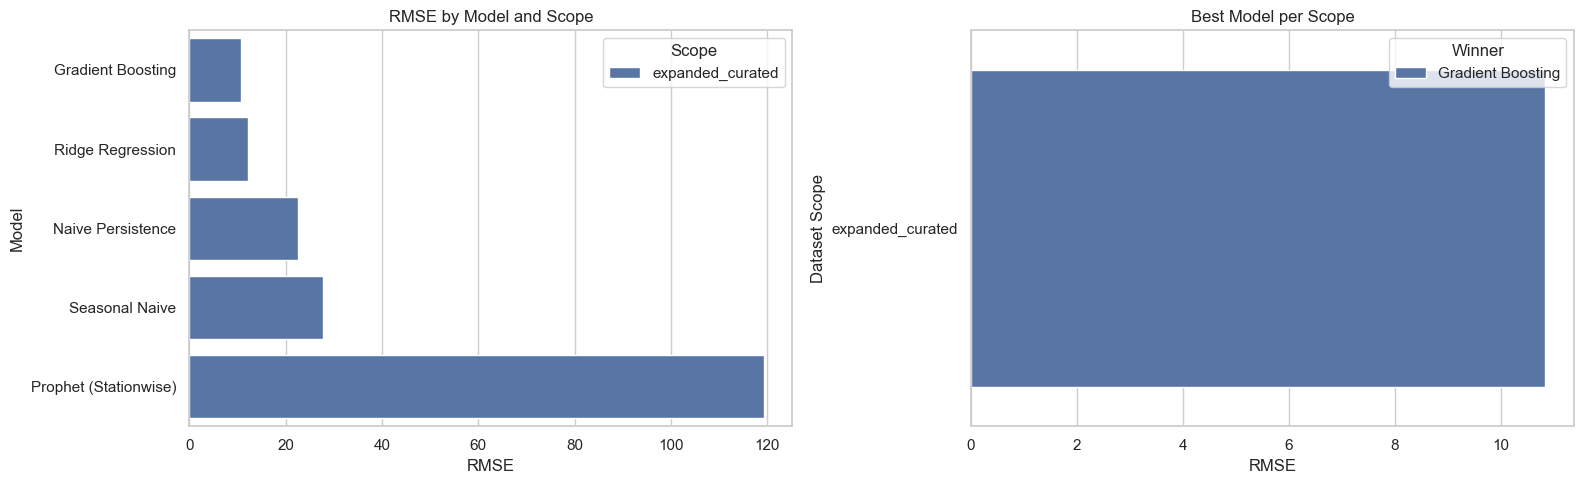

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'single_model_comparison_df' not in globals() or single_model_comparison_df.empty:
    print('Run the final comparison cell first.')
else:
    sns.set_theme(style='whitegrid')
    plot_df = single_model_comparison_df.copy()
    plot_df['model_scope'] = plot_df['model_label'] + ' | ' + plot_df['dataset_scope']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(
        data=plot_df,
        x='rmse',
        y='model_label',
        hue='dataset_scope',
        orient='h',
        ax=axes[0],
    )
    axes[0].set_title('RMSE by Model and Scope')
    axes[0].set_xlabel('RMSE')
    axes[0].set_ylabel('Model')
    axes[0].legend(title='Scope', loc='best')

    if 'best_per_scope_df' in globals() and not best_per_scope_df.empty:
        sns.barplot(
            data=best_per_scope_df,
            x='rmse',
            y='dataset_scope',
            hue='model_label',
            orient='h',
            dodge=False,
            ax=axes[1],
        )
        axes[1].set_title('Best Model per Scope')
        axes[1].set_xlabel('RMSE')
        axes[1].set_ylabel('Dataset Scope')
        axes[1].legend(title='Winner', loc='best')
    else:
        axes[1].text(0.5, 0.5, 'No best-per-scope table yet', ha='center', va='center')
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()

## Offline Pollutant Metric Summary

This section loads the prepared offline forecast metric summaries for `pm25`, `pm10`, `o3`, and `no2`.
Use it as a compact scoreboard for the current champion models across pollutants.

In [37]:
import json
from airpulse.config import OFFLINE_FORECAST_METRICS_FILES

summary_pollutants = ['pm25', 'pm10', 'o3', 'no2']
summary_rows = []

for pollutant in summary_pollutants:
    metrics_path = OFFLINE_FORECAST_METRICS_FILES[pollutant]
    payload = json.loads(metrics_path.read_text(encoding='utf-8')) if metrics_path.exists() else {}
    tournament = payload.get('model_tournament_results') or []
    best_row = tournament[0] if tournament else {}
    summary_rows.append({
        'pollutant': pollutant,
        'target': payload.get('target', ''),
        'best_model_name': payload.get('best_model_name', ''),
        'train_rows': payload.get('train_rows', ''),
        'test_rows': payload.get('test_rows', ''),
        'rows_used_best_model': best_row.get('rows_used', payload.get('test_rows', '')),
        'mae': best_row.get('MAE', None),
        'rmse': best_row.get('RMSE', None),
        'r2': best_row.get('R2', None),
        'mape': best_row.get('MAPE', None),
        'selected_station_config': payload.get('selected_station_config', ''),
        'champion_model_path': payload.get('champion_model_path', ''),
    })

offline_metric_summary_df = pd.DataFrame(summary_rows)
display(offline_metric_summary_df[['pollutant', 'best_model_name', 'train_rows', 'test_rows', 'rows_used_best_model', 'mae', 'rmse', 'r2', 'mape']])

,pollutant,best_model_name,train_rows,test_rows,rows_used_best_model,mae,rmse,r2,mape
0,pm25,tree_ensemble_stress_mix,5204,1301,1301,7.872704,11.200218,0.69531,NaN
1,pm10,random_forest_benchmark,7168,1792,1792,8.321068,12.137332,NaN,28.791209
2,o3,random_forest_benchmark,7136,1785,1785,3.744914,6.006208,NaN,48.589479
3,no2,tree_ensemble_stress_mix,7169,1793,1793,5.387035,7.756707,NaN,39.987103


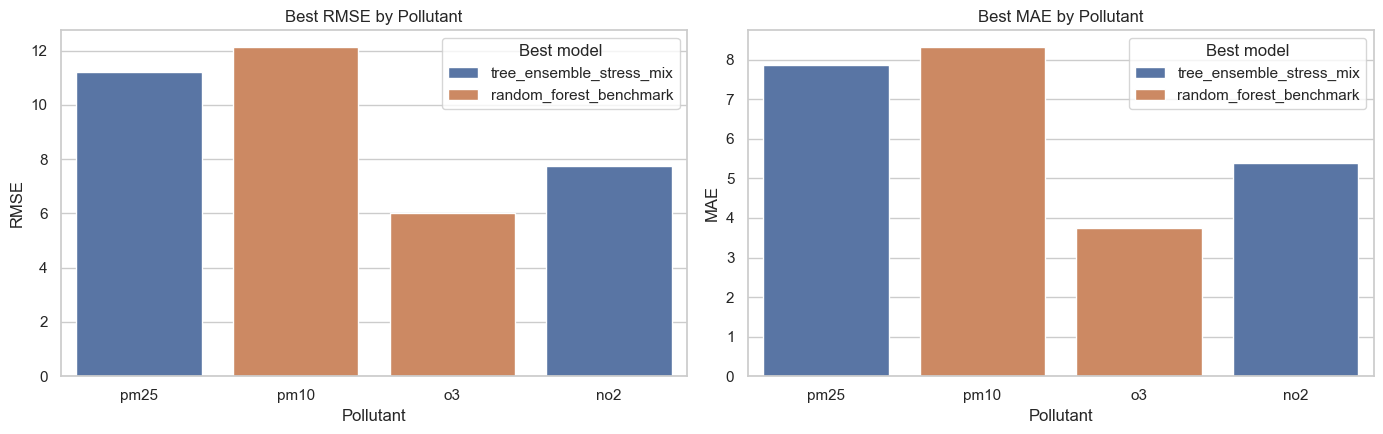

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

if offline_metric_summary_df.empty:
    print('No offline metric summary is available.')
else:
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    sns.barplot(data=offline_metric_summary_df, x='pollutant', y='rmse', hue='best_model_name', ax=axes[0])
    axes[0].set_title('Best RMSE by Pollutant')
    axes[0].set_xlabel('Pollutant')
    axes[0].set_ylabel('RMSE')
    axes[0].legend(title='Best model', loc='best')

    mae_plot_df = offline_metric_summary_df.dropna(subset=['mae']).copy()
    sns.barplot(data=mae_plot_df, x='pollutant', y='mae', hue='best_model_name', ax=axes[1])
    axes[1].set_title('Best MAE by Pollutant')
    axes[1].set_xlabel('Pollutant')
    axes[1].set_ylabel('MAE')
    axes[1].legend(title='Best model', loc='best')

    plt.tight_layout()
    plt.show()

## Save Artifacts

This writes reusable tables under `data/processed/station_expansion/`.


In [39]:
candidate_table_df.to_csv(ARTIFACT_DIR / 'station_candidates.csv', index=False)
accepted_df.to_csv(ARTIFACT_DIR / 'station_candidates_accepted.csv', index=False)
rejected_df.to_csv(ARTIFACT_DIR / 'station_candidates_rejected.csv', index=False)
dataset_scope_summary_df.to_csv(ARTIFACT_DIR / 'dataset_scope_summary.csv', index=False)
recommendation_df.to_csv(ARTIFACT_DIR / 'production_recommendation.csv', index=False)

rolling_paths = save_evaluation_report(rolling_report, output_dir=ARTIFACT_DIR, prefix='rolling')
lso_paths = save_evaluation_report(leave_station_out_report, output_dir=ARTIFACT_DIR, prefix='leave_station_out')

print('Saved rolling report files:')
display(pd.DataFrame({'artifact': list(rolling_paths.keys()), 'path': [str(path) for path in rolling_paths.values()]}))

print('Saved leave-station-out report files:')
display(pd.DataFrame({'artifact': list(lso_paths.keys()), 'path': [str(path) for path in lso_paths.values()]}))


Saved rolling report files:


,artifact,path
0,overall_leaderboard,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
1,per_station_leaderboard,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
2,per_horizon_leaderboard,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
3,dataset_scope_summary,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
4,prediction_rows,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
5,scope_comparison,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
6,manifest,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...


Saved leave-station-out report files:


,artifact,path
0,overall_leaderboard,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
1,per_station_leaderboard,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
2,per_horizon_leaderboard,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
3,dataset_scope_summary,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
4,prediction_rows,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
5,scope_comparison,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
6,manifest,C:\Users\rbeyz\Desktop\AirPulse_Global\data\...
